In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x : '%.4f' % x)
import sys
sys.path.append('..')
from SRC import sp_limpieza_bank as slb 
from SRC import sp_visualizacion as sv
from SRC import sp_eda as se
from SRC import sp_nulos_num as snn
from SRC import sp_outliers as so
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import seaborn as sns
import matplotlib.pyplot as plt 


In [2]:
df = pd.read_csv('../Data/data_limpios_bank.csv')

In [3]:
df.columns

Index(['job_grouped', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'nr_employed', 'y',
       'date', 'latitude', 'longitude', 'id_', 'year', 'age_iterative',
       'euribor3m_iterative'],
      dtype='object')

In [4]:
# 1. Indicador de campaña agresiva (aggressive_campaign = 1 si campaign > percentil 75, si no 0)
p75_campaign = df["campaign"].quantile(0.75)
df["aggressive_campaign"] = (df["campaign"] > p75_campaign).astype(int)

# 2. Duración de las llamadas (long_call = 1 si duration > percentil 75, short_call = 1 si duration < percentil 25)
p75_duration = df["duration"].quantile(0.75)
p25_duration = df["duration"].quantile(0.25)

df["long_call"] = (df["duration"] > p75_duration).astype(int)
df["short_call"] = (df["duration"] < p25_duration).astype(int)


In [5]:
df.columns

Index(['job_grouped', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome',
       'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'nr_employed', 'y',
       'date', 'latitude', 'longitude', 'id_', 'year', 'age_iterative',
       'euribor3m_iterative', 'aggressive_campaign', 'long_call',
       'short_call'],
      dtype='object')

In [6]:
df_metricas = df[['aggressive_campaign','long_call', 'short_call']]

In [7]:
df_metricas.describe().T

,count,mean,std,min,25%,50%,75%,max
aggressive_campaign,43000.0000,0.1852,0.3885,0.0000,0.0000,0.0000,0.0000,1.0000
long_call,43000.0000,0.2490,0.4324,0.0000,0.0000,0.0000,0.0000,1.0000
short_call,43000.0000,0.2471,0.4313,0.0000,0.0000,0.0000,0.0000,1.0000


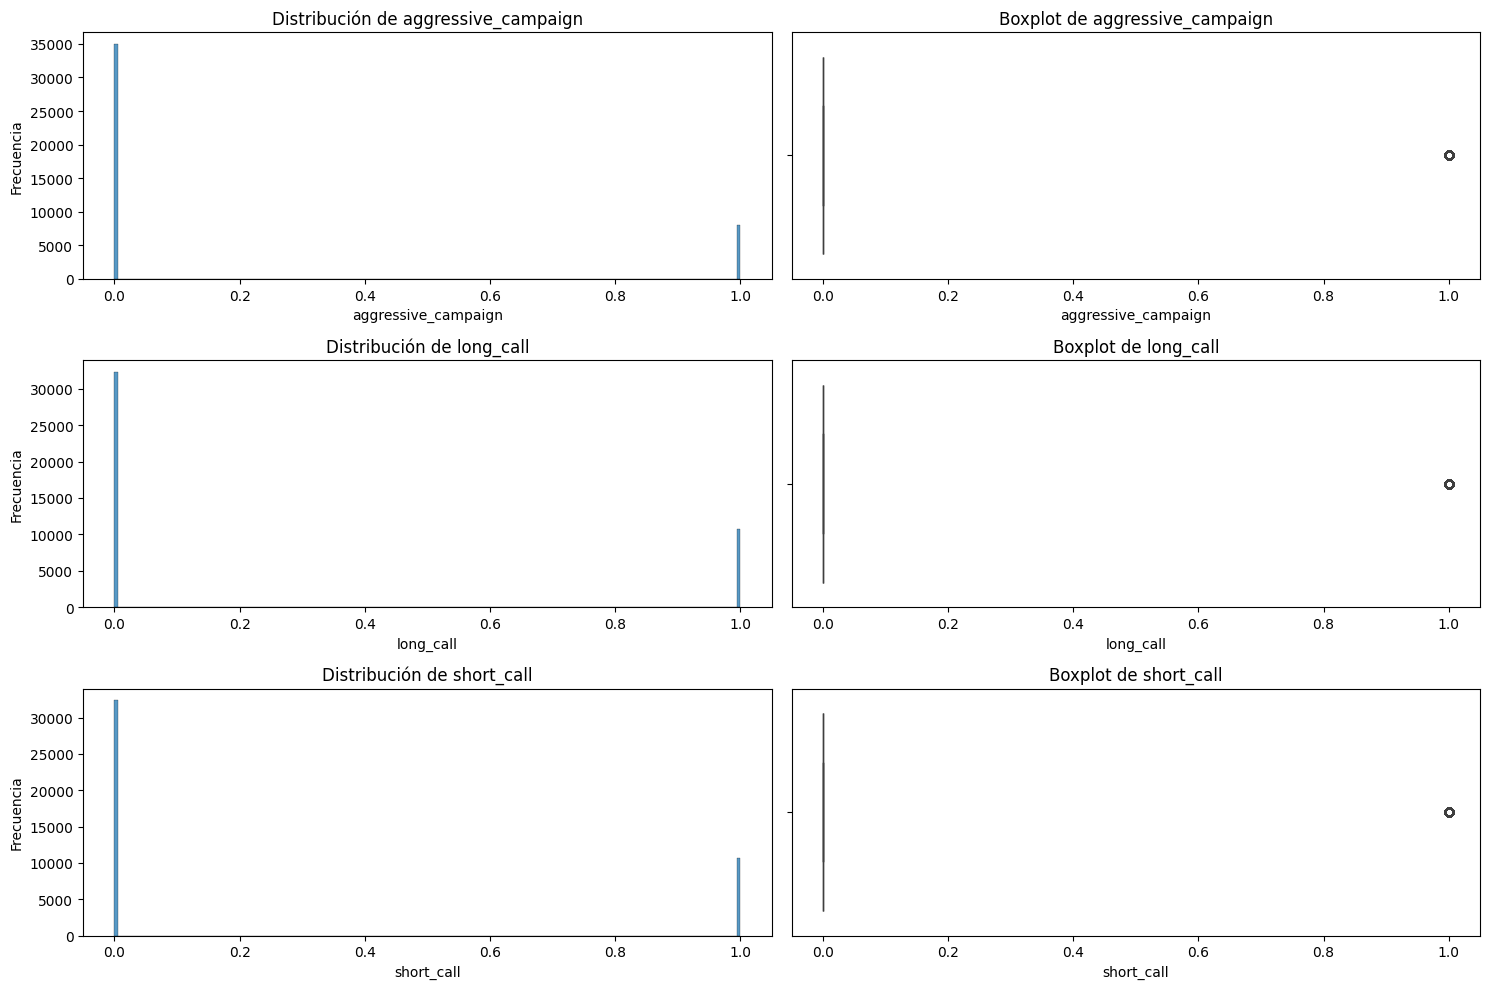

In [8]:
sv.subplot_col_num(df_metricas, df_metricas.columns)

In [12]:
columnas_analizar = ['aggressive_campaign','long_call', 'short_call']
so.contar_outliers(df, columnas_analizar)


,Column,Q1,Q3,IQR,LowerBound,UpperBound,OutlierCount,Outlier%
0,aggressive_campaign,0.0000,0.0000,0.0000,0.0000,0.0000,7964,18.5200
1,long_call,0.0000,0.0000,0.0000,0.0000,0.0000,10707,24.9000
2,short_call,0.0000,0.0000,0.0000,0.0000,0.0000,10625,24.7100


({'aggressive_campaign': 7964, 'long_call': 10707, 'short_call': 10625},
 {'aggressive_campaign': 18.52, 'long_call': 24.9, 'short_call': 24.71})

In [13]:
df.to_csv('../Data/data_metricas_bank.csv', index = False)